In [1]:
!pip install pandas numpy scikit-learn xgboost lightgbm scipy matplotlib seaborn

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 219.9 kB/s eta 0:05:14
   --------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Group 9 - Malayo Ang Lipad, Mababaw Ang Pundasyon: Philippine Export Vulnerability and Trade Potential Analysis Using Machine Learning and Anomaly Detection 


##### Data Import and Preprocessing

##### 1. Growth & Efficiency


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans

# 1. Load Data
df = pd.read_csv('combined.csv')

# 2. Strict Filtering
# Guard against zero/null/negative Quantity and FOB
initial_len = len(df)
df = df[(df['Quantity'] > 0) & (df['FOB'] > 0)].copy()
df.dropna(subset=['Quantity', 'FOB', 'Year', 'Commodity', 'Country Of Destination'], inplace=True)
print(f"Removed {initial_len - len(df)} rows due to zero, negative, or missing values.")

# 3. Create Targets
df['Unit Value'] = df['FOB'] / df['Quantity']
df['Log Unit Value'] = np.log1p(df['Unit Value'])

print("Data Preprocessing Complete. First 5 rows:")
display(df.head())

Removed 9 rows due to zero, negative, or missing values.
Data Preprocessing Complete. First 5 rows:


,Commodity,Country Of Destination,Year,Quantity,FOB,source_file,Unit Value,Log Unit Value
0,Abaca Fibers,Bangladesh,2020,180.00,49500.0,PhilippineExports(2020-2021).csv,275.000000,5.620401
1,Abaca Fibers,Bangladesh,2022,11226.86,27900.0,PhilippineExports(2022-2023).csv,2.485112,1.248500
2,Abaca Fibers,Bangladesh,2024,33750.00,83250.0,PhilippineExports(2024-2025).csv,2.466667,1.243194
3,Abaca Fibers,Egypt Arab Republic,2018,720.00,191880.0,PhilippineExports(2018-2019).csv,266.500000,5.589120
4,Abaca Fibers,Egypt Arab Republic,2019,360.00,85320.0,PhilippineExports(2018-2019).csv,237.000000,5.472271


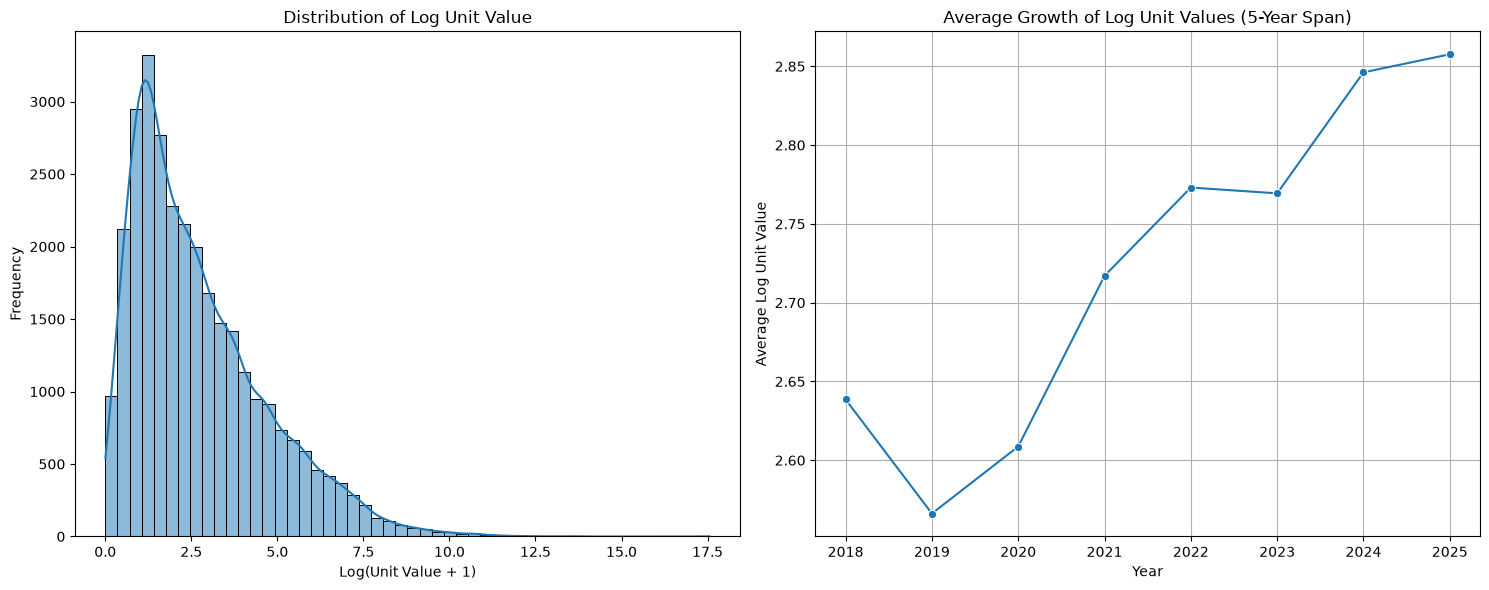

In [3]:
# --- EDA Layer: Plot the distribution and average growth of log unit values ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Log Unit Value'], bins=50, kde=True)
plt.title('Distribution of Log Unit Value')
plt.xlabel('Log(Unit Value + 1)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
avg_log_uv = df.groupby('Year')['Log Unit Value'].mean().reset_index()
sns.lineplot(data=avg_log_uv, x='Year', y='Log Unit Value', marker='o')
plt.title('Average Growth of Log Unit Values (5-Year Span)')
plt.xlabel('Year')
plt.ylabel('Average Log Unit Value')
plt.xticks(avg_log_uv['Year'].astype(int))
plt.grid(True)

plt.tight_layout()
plt.show()

XGBoost Results:
  Train R2: 0.6824 | Train MSE: 1.1916
  Test R2:  0.5935 | Test MSE:  1.5945

Linear Regression Results:
  Train R2: 0.1865 | Train MSE: 3.0525
  Test R2:  0.1837 | Test MSE:  3.2019


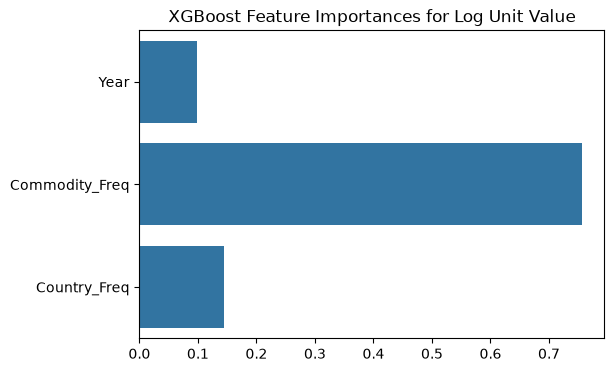

In [4]:
# --- Unit Value Modeling (Linear Regression vs XGBoost) ---

# Prepare Features and Target
X = df[['Year', 'Commodity', 'Country Of Destination']].copy()
y = df['Log Unit Value']

# Train/Test Split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Feature Engineering for XGBoost (Frequency Encoding) ---
freq_commodity = X_train_raw['Commodity'].value_counts(normalize=True)
freq_country = X_train_raw['Country Of Destination'].value_counts(normalize=True)

X_train_xgb = X_train_raw.copy()
X_test_xgb = X_test_raw.copy()

X_train_xgb['Commodity_Freq'] = X_train_xgb['Commodity'].map(freq_commodity).fillna(0)
X_train_xgb['Country_Freq'] = X_train_xgb['Country Of Destination'].map(freq_country).fillna(0)
X_test_xgb['Commodity_Freq'] = X_test_xgb['Commodity'].map(freq_commodity).fillna(0)
X_test_xgb['Country_Freq'] = X_test_xgb['Country Of Destination'].map(freq_country).fillna(0)

features_xgb = ['Year', 'Commodity_Freq', 'Country_Freq']

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=100, max_depth=6)
xgb_model.fit(X_train_xgb[features_xgb], y_train)

y_pred_train_xgb = xgb_model.predict(X_train_xgb[features_xgb])
y_pred_test_xgb = xgb_model.predict(X_test_xgb[features_xgb])

# --- Feature Engineering for Linear Regression (One-Hot Encoding top 10) ---
top_10_commodities = X_train_raw['Commodity'].value_counts().nlargest(10).index
top_10_countries = X_train_raw['Country Of Destination'].value_counts().nlargest(10).index

X_train_lr = X_train_raw.copy()
X_test_lr = X_test_raw.copy()

X_train_lr['Commodity_Group'] = X_train_lr['Commodity'].apply(lambda x: x if x in top_10_commodities else 'Other')
X_train_lr['Country_Group'] = X_train_lr['Country Of Destination'].apply(lambda x: x if x in top_10_countries else 'Other')
X_test_lr['Commodity_Group'] = X_test_lr['Commodity'].apply(lambda x: x if x in top_10_commodities else 'Other')
X_test_lr['Country_Group'] = X_test_lr['Country Of Destination'].apply(lambda x: x if x in top_10_countries else 'Other')

# One-hot encode dropping the first category to avoid dummy variable trap
X_train_lr_encoded = pd.get_dummies(X_train_lr[['Year', 'Commodity_Group', 'Country_Group']], drop_first=True)
# Ensure test set has same columns
X_test_lr_encoded = pd.get_dummies(X_test_lr[['Year', 'Commodity_Group', 'Country_Group']], drop_first=True)
X_test_lr_encoded = X_test_lr_encoded.reindex(columns=X_train_lr_encoded.columns, fill_value=0)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_lr_encoded, y_train)

y_pred_train_lr = lr_model.predict(X_train_lr_encoded)
y_pred_test_lr = lr_model.predict(X_test_lr_encoded)

# --- Reporting Results ---
print("XGBoost Results:")
print(f"  Train R2: {r2_score(y_train, y_pred_train_xgb):.4f} | Train MSE: {mean_squared_error(y_train, y_pred_train_xgb):.4f}")
print(f"  Test R2:  {r2_score(y_test, y_pred_test_xgb):.4f} | Test MSE:  {mean_squared_error(y_test, y_pred_test_xgb):.4f}")

print("\nLinear Regression Results:")
print(f"  Train R2: {r2_score(y_train, y_pred_train_lr):.4f} | Train MSE: {mean_squared_error(y_train, y_pred_train_lr):.4f}")
print(f"  Test R2:  {r2_score(y_test, y_pred_test_lr):.4f} | Test MSE:  {mean_squared_error(y_test, y_pred_test_lr):.4f}")

# Plot XGBoost Feature Importances
plt.figure(figsize=(6, 4))
importances = xgb_model.feature_importances_
sns.barplot(x=importances, y=features_xgb)
plt.title('XGBoost Feature Importances for Log Unit Value')
plt.show()

##### 2. Strengths & Vulnerabilities



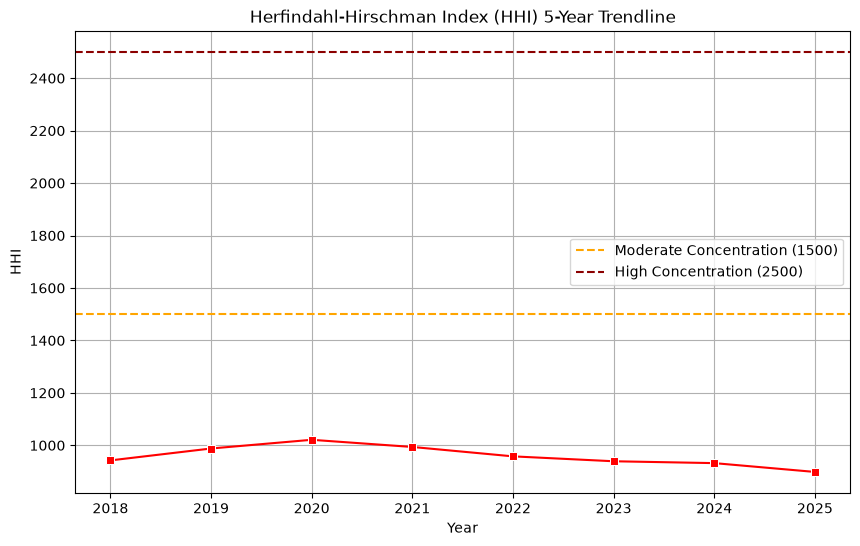

In [5]:
# --- High Market Concentration: HHI Index ---

yearly_totals = df.groupby('Year')['FOB'].sum().reset_index().rename(columns={'FOB': 'Total Yearly FOB'})
country_yearly = df.groupby(['Year', 'Country Of Destination'])['FOB'].sum().reset_index()

country_yearly = pd.merge(country_yearly, yearly_totals, on='Year')
country_yearly['Market Share (%)'] = (country_yearly['FOB'] / country_yearly['Total Yearly FOB']) * 100
country_yearly['Share Squared'] = country_yearly['Market Share (%)'] ** 2

hhi_per_year = country_yearly.groupby('Year')['Share Squared'].sum().reset_index().rename(columns={'Share Squared': 'HHI'})

plt.figure(figsize=(10, 6))
sns.lineplot(data=hhi_per_year, x='Year', y='HHI', marker='s', color='red')
plt.title('Herfindahl-Hirschman Index (HHI) 5-Year Trendline')
plt.xlabel('Year')
plt.ylabel('HHI')
plt.axhline(y=1500, color='orange', linestyle='--', label='Moderate Concentration (1500)')
plt.axhline(y=2500, color='darkred', linestyle='--', label='High Concentration (2500)')
plt.xticks(hhi_per_year['Year'].astype(int))
plt.legend()
plt.grid(True)
plt.show()

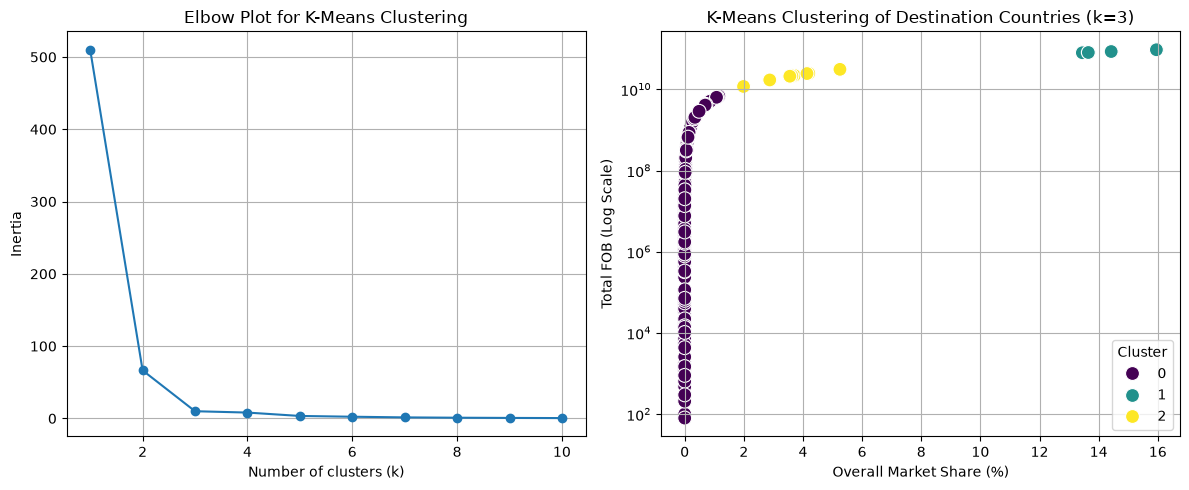

Top 5 Countries and their Clusters:


,Country Of Destination,Total_FOB,Overall Market Share (%),Cluster
240,United States Of America,9.429203e+10,15.952448,1
112,Japan,8.525280e+10,14.423179,1
175,People'S Republic Of China,8.068268e+10,13.650002,1
101,"Hong Kong, China",7.948848e+10,13.447966,1
198,Singapore,3.103411e+10,5.250392,2


In [6]:
# --- High Market Concentration: K-Means Clustering ---

# Aggregate across the entire time span to cluster countries by their overall reliance
country_agg = df.groupby('Country Of Destination').agg(
    Total_FOB=('FOB', 'sum')
).reset_index()

total_fob_all = country_agg['Total_FOB'].sum()
country_agg['Overall Market Share (%)'] = (country_agg['Total_FOB'] / total_fob_all) * 100

# Prepare data for clustering
X_cluster = country_agg[['Total_FOB', 'Overall Market Share (%)']].copy()

# Critical: Scale the data so FOB (millions) doesn't dominate Market Share (0-100)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 1. Elbow Plot to justify k
inertias = []
k_range = range(1, 11)
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Plot for K-Means Clustering')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# 2. Fit final K-Means with k=3 based on assumed/justified elbow
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
country_agg['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.subplot(1, 2, 2)
sns.scatterplot(
    data=country_agg, 
    x='Overall Market Share (%)', 
    y='Total_FOB', 
    hue='Cluster', 
    palette='viridis', 
    s=100
)
plt.yscale('log') # Log scale for better visibility of heavily right-skewed FOB
plt.title(f'K-Means Clustering of Destination Countries (k={k_optimal})')
plt.xlabel('Overall Market Share (%)')
plt.ylabel('Total FOB (Log Scale)')
plt.legend(title='Cluster')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Top 5 Countries and their Clusters:")
display(country_agg.sort_values(by='Total_FOB', ascending=False).head())

##### 3. Shifts & Predictions

